# TME06 Bagging, Boosting

## Imports

In [ ]:
import numpy as np
from mltools import plot_data, plot_frontiere, make_grid, gen_arti
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Forêts aléatoires (Bagging)

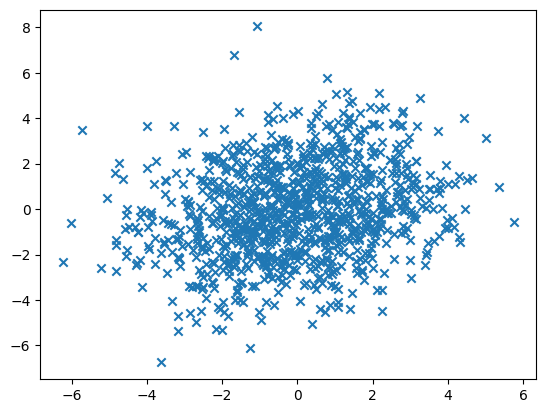

In [87]:
# Nos données artificielles (2D)
np.random.seed(0)
data, y = gen_arti(centerx=1, centery=1, sigma=0.9, nbex=1000, data_type=0, epsilon=1.5)

plot_data(data)

In [88]:
# Séparation en train/test (70% train, 30% test)
data_train, data_test, y_train, y_test = train_test_split(data, y, test_size=0.3, random_state=42)

Nous allons tester différents paramètres (n_estimators : nombre d'arbres, max_depth : profondeur des arbres, min_samples_split : nombre minimum d’échantillons pour diviser un nœud, min_samples_leaf : nombre minimum d’échantillons par feuille) et étudier l'évolution des frontières de décision, de l'erreur en apprentissage et de l'erreur en test.

Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: None, N Estimators: 1, Train Acc: 89.29, Test Acc: 68.67
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: None, N Estimators: 5, Train Acc: 97.00, Test Acc: 76.00
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: None, N Estimators: 50, Train Acc: 100.00, Test Acc: 77.67
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: 1, N Estimators: 1, Train Acc: 68.57, Test Acc: 70.00
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: 1, N Estimators: 5, Train Acc: 78.00, Test Acc: 79.00
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: 1, N Estimators: 50, Train Acc: 77.29, Test Acc: 75.67
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: 5, N Estimators: 1, Train Acc: 79.43, Test Acc: 77.67
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: 5, N Estimators: 5, Train Acc: 81.43, Test Acc: 81.00
Criterion: gini, Min Split: 2, Min Leaf: 1, Max Depth: 5, N Estimators: 50, Train Acc: 82.00, Test Acc: 80.67
Criter

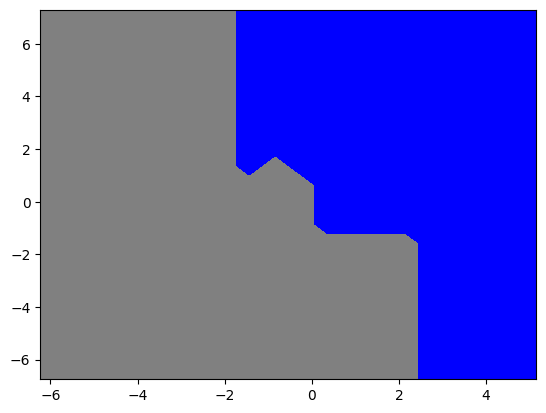

In [90]:
n_estimators_list = [1, 5, 50]
max_depth_list = [None, 1, 5, 50, 100]
min_samples_split_list = [2, 3, 5, 10]
min_samples_leaf_list = [1, 3, 5, 10]

for min_samples_split in min_samples_split_list :
        for min_samples_leaf in min_samples_leaf_list :
            for max_depth in max_depth_list :
                for n_estimators in n_estimators_list :
                    classifier = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, random_state=42)
                    classifier.fit(data_train, y_train.ravel())  # On utilise .ravel() car y_train est un tableau 2D
                    y_pred_train = classifier.predict(data_train)
                    y_pred_test = classifier.predict(data_test)

                    train_acc = (y_pred_train == y_train.ravel()).mean() * 100
                    test_acc = (y_pred_test == y_test.ravel()).mean() * 100

                    print(f"Criterion: {classifier.criterion}, Min Split: {min_samples_split}, Min Leaf: {min_samples_leaf}, "
                          f"Max Depth: {max_depth}, N Estimators: {n_estimators}, "
                          f"Train Acc: {train_acc:.2f}, Test Acc: {test_acc:.2f}")

                    plot_frontiere(data, lambda data: classifier.predict(data))

On observe que sur des données bruitées, plus la profondeur des arbres et le nombre d'arbres des forêts aléatoires augmentent, plus il y a du surapprentissage. Par exemple, pour un modèle avec un nombre minimum d’échantillons par feuille égal à 1, une profondeur de 100 et 50 arbres, l'accuracy sur le train atteint 100%, tandis que sur le test, elle tombe à 77.67%. Cela montre un écart important entre les données d'entraînement et les données de test, typique du surapprentissage : le modèle est trop ajusté aux données d'entraînement et n'arrive pas à généraliser correctement aux nouvelles données.  

Cependant, ce problème de surapprentissage peut être atténué en augmentant le nombre minimum d’échantillons par feuille ou le nombre minimum d’échantillons requis pour diviser un nœud. En faisant cela, on voit que l'accuracy devient plus stable/similaire entre les données d'entraînement et de test. Cela signifie que le modèle ne surapprend plus et devient plus généraliste. On note cependant que l'accuracy (sur train et test) se situe dans une plage de 70-80%. Cela montre que le modèle Random Forest est relativement robuste au surapprentissage grâce au bagging (sous-échantillonnage). En effet, le modèle combine les résultats de plusieurs arbres, ce qui permet de lisser les erreurs : même si un arbre surapprend, la moyenne des prédictions des différents arbres permet de réduire cet effet de surapprentissage.

## AdaBoost (Boosting)

Pour le boosting, on fait la même chose que pour le bagging (test avec différents hyperparamètres) et on compare les deux. 

Rem : On utilise le même classifieur (RandomForestClassifier).

Pour AdaBoost, celui qu'on va devoir écrire, on ajoute un arbre à chaque itération. Pour la profondeur, on peut prendre 1 au début et après on peut tester différentes valeurs comme pour le bagging plus haut.